In [ ]:
import geopandas as gpd

# Example: Replace URL with the published GeoJSON endpoint or your local file
url = 'https://data.austintexas.gov/resource/inrm-c3ee.geojson'
gdf = gpd.read_file(url)


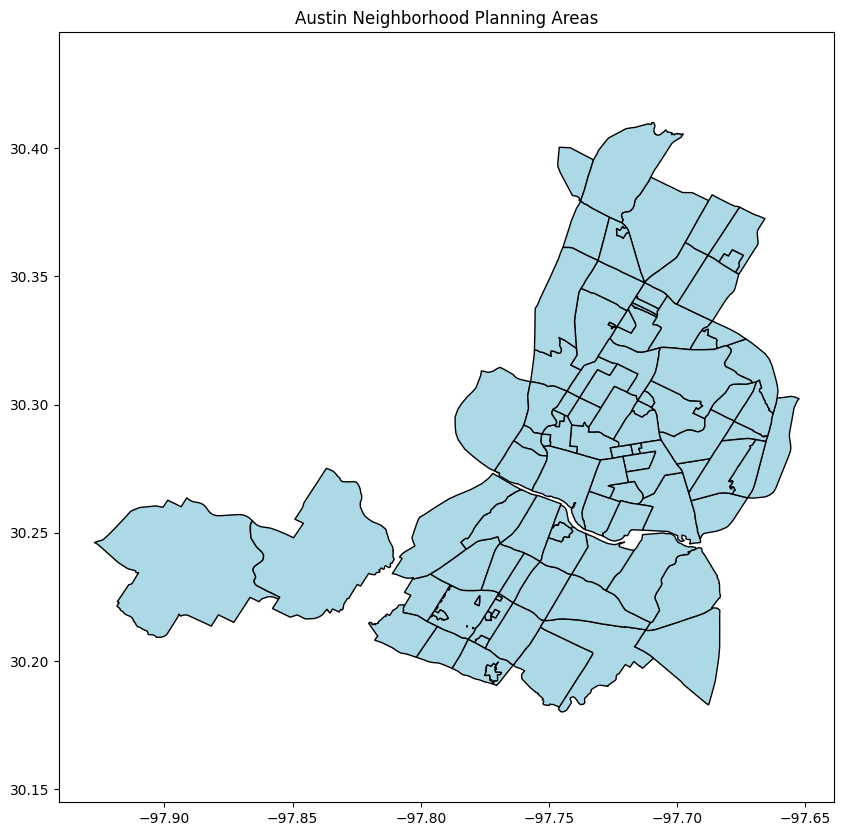

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, color='lightblue', edgecolor='black')
ax.set_title("Austin Neighborhood Planning Areas")
plt.axis('equal')  # For better geographic scaling
plt.show()


In [ ]:
import plotly.express as px

import pandas as pd

url_austin = "https://raw.githubusercontent.com/AHMerrill/housing-project/main/austinhouses.csv"
df_austin = pd.read_csv(url_austin)

fig = px.scatter_mapbox(df_austin, # Use df_austin here
                        lat="latitude",
                        lon="longitude",
                        hover_name="latestPrice",
                        color="zipcode",  # Color code by zipcode
                        zoom=10,
                        height=600,
                        color_continuous_scale=px.colors.qualitative.Alphabet) # Use a qualitative color scale

fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

In [ ]:
import pandas as pd

url_housing_data = "https://raw.githubusercontent.com/AHMerrill/housing-project/main/housing_data_with_neighborhoods.csv"
df_housing_data = pd.read_csv(url_housing_data)
display(df_housing_data.head())

,propertyTaxRate,garageSpaces,hasAssociation,hasGarage,hasSpa,hasView,latestPrice,numOfPhotos,numOfAccessibilityFeatures,numOfAppliances,...,hood_WEST AUSTIN NEIGHBORHOOD GROUP,hood_WEST CONGRESS,hood_WEST OAK HILL,hood_WEST UNIVERSITY,hood_WESTGATE,hood_WINDSOR HILLS,hood_WINDSOR PARK,hood_WINDSOR ROAD,hood_WOOTEN,hood_ZILKER
0,2.21,0,True,False,False,False,687.85,40,0,4,...,False,False,False,False,False,False,False,False,False,False
1,2.21,2,True,True,False,True,409.00,31,0,6,...,False,False,False,False,False,False,False,False,False,False
2,1.98,2,False,True,False,False,199.00,21,1,2,...,False,False,False,False,False,False,False,False,False,False
3,2.21,0,True,False,False,False,400.00,20,0,3,...,False,False,False,False,False,False,False,False,False,False
4,1.98,2,False,True,False,False,240.00,10,0,4,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
display(df_housing_data.columns.tolist())

['propertyTaxRate',
 'garageSpaces',
 'hasAssociation',
 'hasGarage',
 'hasSpa',
 'hasView',
 'latestPrice',
 'numOfPhotos',
 'numOfAccessibilityFeatures',
 'numOfAppliances',
 'numOfParkingFeatures',
 'numOfPatioAndPorchFeatures',
 'numOfSecurityFeatures',
 'numOfWaterfrontFeatures',
 'numOfWindowFeatures',
 'numOfCommunityFeatures',
 'avgSchoolDistance',
 'MedianStudentsPerTeacher',
 'numOfBathrooms',
 'numOfBedrooms',
 'numOfStories',
 'days_since_sale',
 'log_lotSizeSqFt',
 'log_livingAreaSqFt',
 'log_avgSchoolSize',
 'yearsOld_sq',
 'avgSchoolRating_sq',
 'word_count_good',
 'word_count_bad',
 'hood_ALLANDALE',
 'hood_BARTON HILLS',
 'hood_BOULDIN CREEK',
 'hood_BRENTWOOD',
 'hood_CENTRAL EAST AUSTIN',
 'hood_CHESTNUT',
 'hood_CORONADO HILLS',
 'hood_CRESTVIEW',
 'hood_DAWSON',
 'hood_EAST CESAR CHAVEZ',
 'hood_EAST CONGRESS',
 'hood_EAST OAK HILL',
 'hood_FRANKLIN PARK',
 'hood_GALINDO',
 'hood_GARRISON PARK',
 'hood_GEORGIAN ACRES',
 'hood_GOVALLE',
 'hood_HANCOCK',
 'hood_HERIT

In [ ]:
display(df_austin.columns.tolist())

['streetAddress',
 'zipcode',
 'description',
 'latitude',
 'longitude',
 'propertyTaxRate',
 'garageSpaces',
 'hasAssociation',
 'hasGarage',
 'hasSpa',
 'hasView',
 'homeType',
 'yearBuilt',
 'latestPrice',
 'latest_saledate',
 'latest_salemonth',
 'latest_saleyear',
 'numOfPhotos',
 'numOfAccessibilityFeatures',
 'numOfAppliances',
 'numOfParkingFeatures',
 'numOfPatioAndPorchFeatures',
 'numOfSecurityFeatures',
 'numOfWaterfrontFeatures',
 'numOfWindowFeatures',
 'numOfCommunityFeatures',
 'lotSizeSqFt',
 'livingAreaSqFt',
 'avgSchoolDistance',
 'avgSchoolRating',
 'avgSchoolSize',
 'MedianStudentsPerTeacher',
 'numOfBathrooms',
 'numOfBedrooms',
 'numOfStories']

In [ ]:
from geopy.geocoders import Nominatim
import time

geolocator = Nominatim(user_agent="geoapiExercises")

def get_neighborhood(row):
    latitude = row['latitude']
    longitude = row['longitude']
    try:
        location = geolocator.reverse((latitude, longitude), exactly_one=True, timeout=10)
        time.sleep(1)
        if location and location.raw:
            address = location.raw.get('address', {})
            # Prioritize relevant fields based on the structure you showed
            return (
                address.get('neighbourhood') or
                address.get('residential') or
                address.get('suburb') or
                address.get('city_district') or
                address.get('road')  # fallback if nothing else
            )
        else:
            print(f"No location found for: ({latitude}, {longitude})")
            return None
    except Exception as e:
        print(f"Error for ({latitude}, {longitude}): {e}")
        return None

df_austin.loc[df_austin.head(2).index, 'neighborhood'] = df_austin.head(2).apply(get_neighborhood, axis=1)

display(df_austin.head(2))


Error for (30.4864082336426, -97.7947235107422): HTTPSConnectionPool(host='nominatim.openstreetmap.org', port=443): Max retries exceeded with url: /reverse?lat=30.4864082336426&lon=-97.7947235107422&format=json&addressdetails=1 (Caused by NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x795563637790>: Failed to establish a new connection: [Errno 111] Connection refused'))
Error for (30.4943752288818, -97.796516418457): HTTPSConnectionPool(host='nominatim.openstreetmap.org', port=443): Max retries exceeded with url: /reverse?lat=30.4943752288818&lon=-97.796516418457&format=json&addressdetails=1 (Caused by NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x795563639850>: Failed to establish a new connection: [Errno 111] Connection refused'))


,streetAddress,zipcode,description,latitude,longitude,propertyTaxRate,garageSpaces,hasAssociation,hasGarage,hasSpa,...,lotSizeSqFt,livingAreaSqFt,avgSchoolDistance,avgSchoolRating,avgSchoolSize,MedianStudentsPerTeacher,numOfBathrooms,numOfBedrooms,numOfStories,neighborhood
0,10505 Cannon Mark Way,78717,*PLEASE SEE THE WALKTHROUGH VIRTUAL TOUR*This ...,30.486408,-97.794724,2.21,0,True,False,False,...,10672.0,4564,3.266667,7.666667,1259,14,6.0,5,2,None
1,15524 Staked Plains Loop,78717,Rare opportunity in this high demand area of A...,30.494375,-97.796516,2.21,2,True,True,False,...,9060.0,3233,1.933333,8.333333,1481,16,4.0,5,2,None


In [64]:
import requests
response = requests.get("https://nominatim.openstreetmap.org")
print(response.status_code)

#Blocked on GPU from colab, attempting with geo libraries below.

ConnectionError: HTTPSConnectionPool(host='nominatim.openstreetmap.org', port=443): Max retries exceeded with url: / (Caused by NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x795556803e90>: Failed to establish a new connection: [Errno 111] Connection refused'))

In [ ]:
!pip install opencage

In [ ]:
from opencage.geocoder import OpenCageGeocode
import time

key = '32f75ef54dfb4885ba997b6f7846a95e'  # Replace this with your real API key
geocoder = OpenCageGeocode(key)

def get_neighborhood_opencage(row):
    """
    Gets the neighborhood or residential area for a given row using OpenCage Geocoding.
    Includes a small delay to avoid hitting rate limits.
    """
    latitude = row['latitude']
    longitude = row['longitude']
    try:
        result = geocoder.reverse_geocode(latitude, longitude)
        time.sleep(1) # Keep the delay as requested

        if result and result[0] and 'components' in result[0]:
            address = result[0]['components']
            return (
                address.get('neighbourhood') or
                address.get('residential')
            )
        else:
            # Print a message for cases where no valid result or components are found
            print(f"No valid result or components found for coordinates ({latitude}, {longitude})")
            return None
    except Exception as e:
        print(f"Error processing coordinates ({latitude}, {longitude}): {e}")
        return None

# Apply the function to the first 2 rows of the DataFrame for testing
df_austin.loc[df_austin.head(2).index, 'neighborhood'] = df_austin.head(2).apply(get_neighborhood_opencage, axis=1)
display(df_austin.head(2))

,streetAddress,zipcode,description,latitude,longitude,propertyTaxRate,garageSpaces,hasAssociation,hasGarage,hasSpa,...,lotSizeSqFt,livingAreaSqFt,avgSchoolDistance,avgSchoolRating,avgSchoolSize,MedianStudentsPerTeacher,numOfBathrooms,numOfBedrooms,numOfStories,neighborhood
0,10505 Cannon Mark Way,78717,*PLEASE SEE THE WALKTHROUGH VIRTUAL TOUR*This ...,30.486408,-97.794724,2.21,0,True,False,False,...,10672.0,4564,3.266667,7.666667,1259,14,6.0,5,2,Estates
1,15524 Staked Plains Loop,78717,Rare opportunity in this high demand area of A...,30.494375,-97.796516,2.21,2,True,True,False,...,9060.0,3233,1.933333,8.333333,1481,16,4.0,5,2,Granite Shoals


No valid neighborhood or residential found for coordinates (30.2557067871094, -97.5769577026367)
No valid neighborhood or residential found for coordinates (30.4956378936768, -97.7978744506836)
Latitude: 30.4864082336426, Longitude: -97.7947235107422, Neighborhood: None, Residential: Estates
Latitude: 30.4943752288818, Longitude: -97.796516418457, Neighborhood: None, Residential: Granite Shoals
Latitude: 30.2557067871094, Longitude: -97.5769577026367, Neighborhood: None, Residential: None
Latitude: 30.4956378936768, Longitude: -97.7978744506836, Neighborhood: None, Residential: None
Latitude: 30.233154296875, Longitude: -97.5873184204102, Neighborhood: None, Residential: Austin's Colony


In [ ]:
import pandas as pd

url_housing_data = "https://raw.githubusercontent.com/AHMerrill/housing-project/main/housing_data_with_neighborhoods.csv"
df_housing_data = pd.read_csv(url_housing_data)
display(df_housing_data.head())



,propertyTaxRate,garageSpaces,hasAssociation,hasGarage,hasSpa,hasView,latestPrice,numOfPhotos,numOfAccessibilityFeatures,numOfAppliances,...,hood_WEST AUSTIN NEIGHBORHOOD GROUP,hood_WEST CONGRESS,hood_WEST OAK HILL,hood_WEST UNIVERSITY,hood_WESTGATE,hood_WINDSOR HILLS,hood_WINDSOR PARK,hood_WINDSOR ROAD,hood_WOOTEN,hood_ZILKER
0,2.21,0,True,False,False,False,687.85,40,0,4,...,False,False,False,False,False,False,False,False,False,False
1,2.21,2,True,True,False,True,409.00,31,0,6,...,False,False,False,False,False,False,False,False,False,False
2,1.98,2,False,True,False,False,199.00,21,1,2,...,False,False,False,False,False,False,False,False,False,False
3,2.21,0,True,False,False,False,400.00,20,0,3,...,False,False,False,False,False,False,False,False,False,False
4,1.98,2,False,True,False,False,240.00,10,0,4,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
display(df_housing_data.columns.tolist())

['propertyTaxRate',
 'garageSpaces',
 'hasAssociation',
 'hasGarage',
 'hasSpa',
 'hasView',
 'latestPrice',
 'numOfPhotos',
 'numOfAccessibilityFeatures',
 'numOfAppliances',
 'numOfParkingFeatures',
 'numOfPatioAndPorchFeatures',
 'numOfSecurityFeatures',
 'numOfWaterfrontFeatures',
 'numOfWindowFeatures',
 'numOfCommunityFeatures',
 'avgSchoolDistance',
 'MedianStudentsPerTeacher',
 'numOfBathrooms',
 'numOfBedrooms',
 'numOfStories',
 'days_since_sale',
 'log_lotSizeSqFt',
 'log_livingAreaSqFt',
 'log_avgSchoolSize',
 'yearsOld_sq',
 'avgSchoolRating_sq',
 'word_count_good',
 'word_count_bad',
 'hood_ALLANDALE',
 'hood_BARTON HILLS',
 'hood_BOULDIN CREEK',
 'hood_BRENTWOOD',
 'hood_CENTRAL EAST AUSTIN',
 'hood_CHESTNUT',
 'hood_CORONADO HILLS',
 'hood_CRESTVIEW',
 'hood_DAWSON',
 'hood_EAST CESAR CHAVEZ',
 'hood_EAST CONGRESS',
 'hood_EAST OAK HILL',
 'hood_FRANKLIN PARK',
 'hood_GALINDO',
 'hood_GARRISON PARK',
 'hood_GEORGIAN ACRES',
 'hood_GOVALLE',
 'hood_HANCOCK',
 'hood_HERIT

# Task
Perform a Random Forest regression on the `df_housing_data` DataFrame to predict `log_latestPrice` using a 70/30 train-test split.

## Prepare data

### Subtask:
Select the features (independent variables) and the target variable (`log_latestPrice`) from the `df_housing_data` DataFrame.


**Reasoning**:
Select the target and feature columns from the DataFrame.



In [ ]:
target = 'latestPrice' # Check 1
import numpy as np
from sklearn.model_selection import train_test_split
all_columns = df_housing_data.columns.tolist()
features = [col for col in all_columns if col != target]
X = df_housing_data[features]
y = df_housing_data[target]

,propertyTaxRate,garageSpaces,hasAssociation,hasGarage,hasSpa,hasView,numOfPhotos,numOfAccessibilityFeatures,numOfAppliances,numOfParkingFeatures,...,hood_WEST AUSTIN NEIGHBORHOOD GROUP,hood_WEST CONGRESS,hood_WEST OAK HILL,hood_WEST UNIVERSITY,hood_WESTGATE,hood_WINDSOR HILLS,hood_WINDSOR PARK,hood_WINDSOR ROAD,hood_WOOTEN,hood_ZILKER
0,2.21,0,True,False,False,False,40,0,4,2,...,False,False,False,False,False,False,False,False,False,False
1,2.21,2,True,True,False,True,31,0,6,3,...,False,False,False,False,False,False,False,False,False,False
2,1.98,2,False,True,False,False,21,1,2,2,...,False,False,False,False,False,False,False,False,False,False
3,2.21,0,True,False,False,False,20,0,3,2,...,False,False,False,False,False,False,False,False,False,False
4,1.98,2,False,True,False,False,10,0,4,2,...,False,False,False,False,False,False,False,False,False,False


,latestPrice
0,687.85
1,409.00
2,199.00
3,400.00
4,240.00


**Reasoning**:
The target variable for the regression is `log_latestPrice`, not `latestPrice`. I need to create a new column for the log of the latest price and then use that as the target.



In [ ]:
df_housing_data['log_latestPrice'] = np.log(df_housing_data['latestPrice'])
target = 'log_latestPrice'
all_columns = df_housing_data.columns.tolist()
features = [col for col in all_columns if col not in [target, 'latestPrice']]
X = df_housing_data[features]
y = df_housing_data[target]

,propertyTaxRate,garageSpaces,hasAssociation,hasGarage,hasSpa,hasView,numOfPhotos,numOfAccessibilityFeatures,numOfAppliances,numOfParkingFeatures,...,hood_WEST AUSTIN NEIGHBORHOOD GROUP,hood_WEST CONGRESS,hood_WEST OAK HILL,hood_WEST UNIVERSITY,hood_WESTGATE,hood_WINDSOR HILLS,hood_WINDSOR PARK,hood_WINDSOR ROAD,hood_WOOTEN,hood_ZILKER
0,2.21,0,True,False,False,False,40,0,4,2,...,False,False,False,False,False,False,False,False,False,False
1,2.21,2,True,True,False,True,31,0,6,3,...,False,False,False,False,False,False,False,False,False,False
2,1.98,2,False,True,False,False,21,1,2,2,...,False,False,False,False,False,False,False,False,False,False
3,2.21,0,True,False,False,False,20,0,3,2,...,False,False,False,False,False,False,False,False,False,False
4,1.98,2,False,True,False,False,10,0,4,2,...,False,False,False,False,False,False,False,False,False,False


,log_latestPrice
0,6.533571
1,6.013715
2,5.293305
3,5.991465
4,5.480639


## Split data

### Subtask:
Split the data into training and testing sets using a 70/30 ratio.


**Reasoning**:
Split the data into training and testing sets using a 70/30 ratio.



In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


Shape of X_train: (4752, 88)
Shape of X_test: (2037, 88)
Shape of y_train: (4752,)
Shape of y_test: (2037,)


## Train model

### Subtask:
Train a Random Forest Regressor model on the training data.


**Reasoning**:
Import RandomForestRegressor and train the model on the training data.



In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Instantiate a RandomForestRegressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Fit the model to the training data
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

## Evaluate model

### Subtask:
Evaluate the trained model's performance on the testing data using appropriate regression metrics (e.g., Mean Absolute Error, Mean Squared Error, R-squared).


**Reasoning**:
Evaluate the trained model's performance on the testing data using appropriate regression metrics.



In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np  # Import numpy for exponentiation

# Make predictions on the testing features (these are on the log scale)
y_pred_log = rf_model.predict(X_test)

# Calculate evaluation metrics on the log scale
mae_log = mean_absolute_error(y_test, y_pred_log)
mse_log = mean_squared_error(y_test, y_pred_log)
r2_log = r2_score(y_test, y_pred_log)

# Print the metrics on the log scale
print(f"Log Scale Metrics:")
print(f"Mean Absolute Error (MAE): {mae_log}")
print(f"Mean Squared Error (MSE): {mse_log}")
print(f"R-squared (R2): {r2_log}")

# Convert actual and predicted values back to the original dollar scale (thousands of dollars)
y_test_thousands_dollars = np.exp(y_test)
y_pred_thousands_dollars = np.exp(y_pred_log)

# Calculate evaluation metrics on the original dollar scale (actual dollars)
# Since the original scale was thousands of dollars, multiply by (1000)^2 for MSE
mse_actual_dollars = mean_squared_error(y_test_thousands_dollars, y_pred_thousands_dollars) * (1000)
r2_actual_dollars = r2_score(y_test_thousands_dollars, y_pred_thousands_dollars)


print("\nActual Dollar Scale Metrics:")
print(f"Mean Squared Error (MSE): ${mse_actual_dollars:,.2f}")
print(f"R-squared (R2): {r2_actual_dollars}")


print("\n--- Feature Importances ---")

# Get feature importances from the trained model
# Assuming rf_model and feature_columns are available from previous cell execution
if 'rf_model' in locals() and 'feature_columns' in locals():
    importances = rf_model.feature_importances_
    feature_importances = pd.Series(importances, index=feature_columns)
    sorted_importances = feature_importances.sort_values(ascending=False)
    print("Top 10 Most Important Features:")
    display(sorted_importances.head(10))
else:
    print("Random Forest model or feature columns not found. Please run the model training cell first.")

Log Scale Metrics:
Mean Absolute Error (MAE): 0.1741492197859354
Mean Squared Error (MSE): 0.07075174012445151
R-squared (R2): 0.7198629336351605

Actual Dollar Scale Metrics:
Mean Squared Error (MSE): $78,115,734.87
R-squared (R2): 0.6680177239987382

--- Feature Importances ---
Top 10 Most Important Features:


,0
log_livingAreaSqFt,0.353644
avgSchoolRating_sq,0.149700
log_avgSchoolSize,0.088077
yearsOld_sq,0.056834
log_lotSizeSqFt,0.053503
avgSchoolDistance,0.042903
hasAssociation,0.041713
days_since_sale,0.037818
numOfPhotos,0.023174
numOfBathrooms,0.016859


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def run_random_forest(df, target_col='log_latestPrice', test_size=0.3, random_state=42, n_estimators=100):
    # Separate features and target
    # Exclude both the target column and 'latestPrice' from features
    features = [col for col in df.columns if col not in [target_col, 'latestPrice']]
    X = df[features]
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    rf = RandomForestRegressor(n_estimators=n_estimators, random_state=random_state)
    rf.fit(X_train, y_train)

    y_pred_log = rf.predict(X_test)
    mse_log = mean_squared_error(y_test, y_pred_log)
    r2_log = r2_score(y_test, y_pred_log)
    y_pred_thousands_dollars = np.exp(y_pred_log)
    y_test_thousands_dollars = np.exp(y_test)
    mse_actual_dollars = mean_squared_error(y_test_thousands_dollars, y_pred_thousands_dollars) * (1000**2)
    # For RMSE, multiply by 1000
    rmse_actual_dollars = np.sqrt(mse_actual_dollars)


    print(f"--- Random Forest Results ---")
    print(f"Log MSE: {mse_log:.4f}")
    print(f"Log R²: {r2_log:.4f}")
    print(f"--- Actual Dollar Scale ---")
    print(f"MSE (actual dollars): ${mse_actual_dollars:,.2f}")
    print(f"RMSE (actual dollars): ${rmse_actual_dollars:,.2f}")

    return rf, X_train.columns

In [ ]:
run_random_forest(df_housing_data)

--- Random Forest Results ---
Log MSE: 0.0708
Log R²: 0.7199
--- Actual Dollar Scale ---
MSE (actual dollars): $39,057,867,435.03
RMSE (actual dollars): $197,630.63


(RandomForestRegressor(random_state=42),
 Index(['propertyTaxRate', 'garageSpaces', 'hasAssociation', 'hasGarage',
        'hasSpa', 'hasView', 'numOfPhotos', 'numOfAccessibilityFeatures',
        'numOfAppliances', 'numOfParkingFeatures', 'numOfPatioAndPorchFeatures',
        'numOfSecurityFeatures', 'numOfWaterfrontFeatures',
        'numOfWindowFeatures', 'numOfCommunityFeatures', 'avgSchoolDistance',
        'MedianStudentsPerTeacher', 'numOfBathrooms', 'numOfBedrooms',
        'numOfStories', 'days_since_sale', 'log_lotSizeSqFt',
        'log_livingAreaSqFt', 'log_avgSchoolSize', 'yearsOld_sq',
        'avgSchoolRating_sq', 'word_count_good', 'word_count_bad',
        'hood_ALLANDALE', 'hood_BARTON HILLS', 'hood_BOULDIN CREEK',
        'hood_BRENTWOOD', 'hood_CENTRAL EAST AUSTIN', 'hood_CHESTNUT',
        'hood_CORONADO HILLS', 'hood_CRESTVIEW', 'hood_DAWSON',
        'hood_EAST CESAR CHAVEZ', 'hood_EAST CONGRESS', 'hood_EAST OAK HILL',
        'hood_FRANKLIN PARK', 'hood_GALINDO'

In [ ]:
import pandas as pd

rf_model, feature_columns = run_random_forest(df_housing_data)
importances = rf_model.feature_importances_
feature_importances = pd.Series(importances, index=feature_columns)
sorted_importances = feature_importances.sort_values(ascending=False)
print("Top 10 Most Important Features:")
display(sorted_importances.head(30))

--- Random Forest Results ---
Log MSE: 0.0708
Log R²: 0.7199
--- Actual Dollar Scale ---
MSE (actual dollars): $39,057,867,435.03
RMSE (actual dollars): $197,630.63
Top 10 Most Important Features:


,0
log_livingAreaSqFt,0.353644
avgSchoolRating_sq,0.149700
log_avgSchoolSize,0.088077
yearsOld_sq,0.056834
log_lotSizeSqFt,0.053503
avgSchoolDistance,0.042903
hasAssociation,0.041713
days_since_sale,0.037818
numOfPhotos,0.023174
numOfBathrooms,0.016859
